# Inferential Statistics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/statistics/02_inferential_statistics.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Sampling distributions
- Confidence intervals
- Point estimation vs interval estimation
- Margin of error
- Standard error

## Why Inferential Statistics?

You can't always collect data from entire populations. Inferential stats let you draw conclusions about populations from samples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print("Inferential Statistics: Drawing conclusions from samples")

Inferential Statistics: Drawing conclusions from samples


---
## 1. Sampling Distributions

In [2]:
# Population: infinite, we don't have all data
# Sample: subset we actually collect
# Sample Mean: estimate of population mean

# Simulate true population
population = np.random.normal(100, 15, 100000)
true_mean = np.mean(population)
true_std = np.std(population)

print(f"True Population:")
print(f"  Mean: {true_mean:.2f}")
print(f"  Std Dev: {true_std:.2f}")

True Population:
  Mean: 100.01
  Std Dev: 15.01


In [3]:
# Take many samples, track their means
sample_size = 30
num_samples = 1000
sample_means = []

for i in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

print(f"\nSample Statistics (n={sample_size}, {num_samples} samples):")
print(f"  Mean of sample means: {np.mean(sample_means):.2f}")
print(f"  Std error (SEM): {np.std(sample_means):.2f}")
print(f"\nTheoretical SEM = σ/√n = {true_std/np.sqrt(sample_size):.2f}")


Sample Statistics (n=30, 1000 samples):
  Mean of sample means: 99.97
  Std error (SEM): 2.78

Theoretical SEM = σ/√n = 2.74


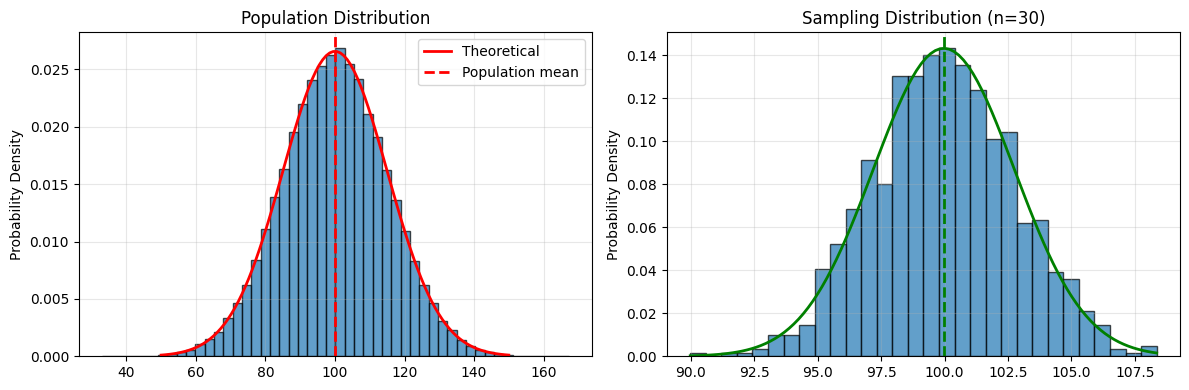

Key insight: Sampling distribution is narrower than population!
Spread narrows by factor of √n = √30 ≈ 5.5


In [4]:
# Visualize sampling distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Population
axes[0].hist(population, bins=50, edgecolor='black', alpha=0.7, density=True)
x = np.linspace(50, 150, 100)
axes[0].plot(x, stats.norm.pdf(x, true_mean, true_std), 'r-', linewidth=2, label='Theoretical')
axes[0].axvline(true_mean, color='red', linestyle='--', linewidth=2, label='Population mean')
axes[0].set_title('Population Distribution')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sampling distribution
axes[1].hist(sample_means, bins=30, edgecolor='black', alpha=0.7, density=True)
sem = np.std(sample_means)
x_sem = np.linspace(sample_means.min(), sample_means.max(), 100)
axes[1].plot(x_sem, stats.norm.pdf(x_sem, np.mean(sample_means), sem), 'g-', linewidth=2)
axes[1].axvline(np.mean(sample_means), color='green', linestyle='--', linewidth=2)
axes[1].set_title(f'Sampling Distribution (n={sample_size})')
axes[1].set_ylabel('Probability Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: Sampling distribution is narrower than population!")
print(f"Spread narrows by factor of √n = √{sample_size} ≈ {np.sqrt(sample_size):.1f}")

---
## 2. Confidence Intervals

In [5]:
# Confidence Interval = range likely to contain true parameter
# 95% CI means we're 95% confident true value is in this range

# Single sample
sample = np.random.choice(population, size=30, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # Sample std (unbiased)
sample_size = len(sample)

# Standard error
sem = sample_std / np.sqrt(sample_size)

# Critical value for 95% CI
confidence = 0.95
alpha = 1 - confidence
t_critical = stats.t.ppf(1 - alpha/2, df=sample_size-1)

# Confidence interval
ci_lower = sample_mean - t_critical * sem
ci_upper = sample_mean + t_critical * sem

print(f"Sample of {sample_size} values:")
print(f"  Sample mean: {sample_mean:.2f}")
print(f"  Sample std: {sample_std:.2f}")
print(f"  Standard Error: {sem:.2f}")
print(f"\n95% Confidence Interval:")
print(f"  [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"\nInterpretation: We're 95% confident the true population mean")
print(f"is between {ci_lower:.2f} and {ci_upper:.2f}")
print(f"\nDoes it contain true mean {true_mean:.2f}? {ci_lower <= true_mean <= ci_upper}")

Sample of 30 values:
  Sample mean: 103.74
  Sample std: 15.28
  Standard Error: 2.79

95% Confidence Interval:
  [98.04, 109.44]

Interpretation: We're 95% confident the true population mean
is between 98.04 and 109.44

Does it contain true mean 100.01? True


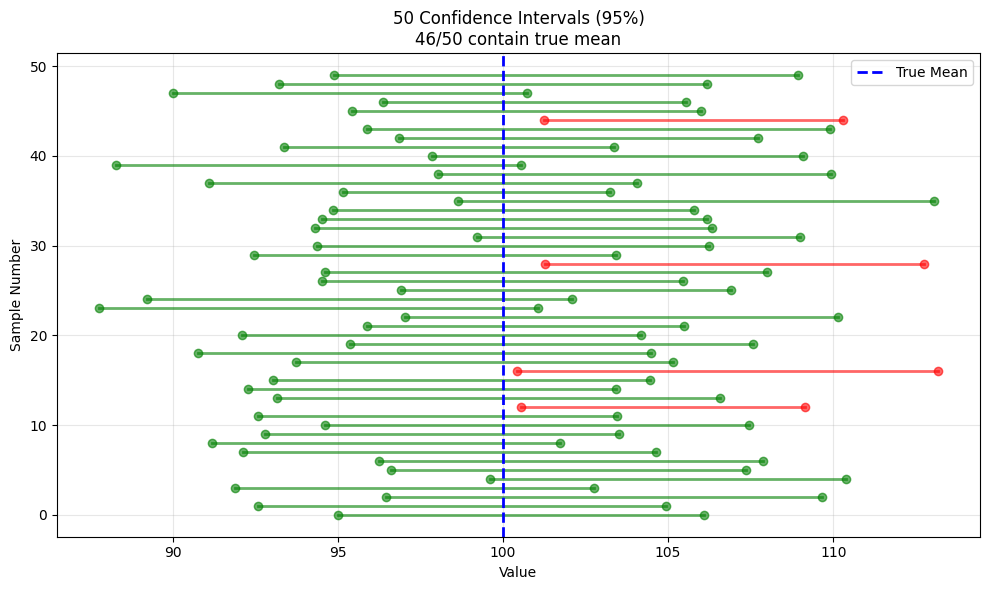


Out of 50 samples: 46 CIs contained the true mean
Expected: ~47-48 (95% of 50)


In [6]:
# Visualize: multiple CI attempts
fig, ax = plt.subplots(figsize=(10, 6))

num_intervals = 50
contains_true = 0

for i in range(num_intervals):
    sample = np.random.choice(population, size=30, replace=False)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    sem = sample_std / np.sqrt(30)
    ci_lower = sample_mean - t_critical * sem
    ci_upper = sample_mean + t_critical * sem
    
    contains = ci_lower <= true_mean <= ci_upper
    if contains:
        contains_true += 1
        color = 'green'
    else:
        color = 'red'
    
    ax.plot([ci_lower, ci_upper], [i, i], 'o-', color=color, alpha=0.6, linewidth=2)

ax.axvline(true_mean, color='blue', linestyle='--', linewidth=2, label='True Mean')
ax.set_xlabel('Value')
ax.set_ylabel('Sample Number')
ax.set_title(f'50 Confidence Intervals (95%)\n{contains_true}/50 contain true mean')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOut of 50 samples: {contains_true} CIs contained the true mean")
print(f"Expected: ~47-48 (95% of 50)")

---
## 3. Effect of Sample Size

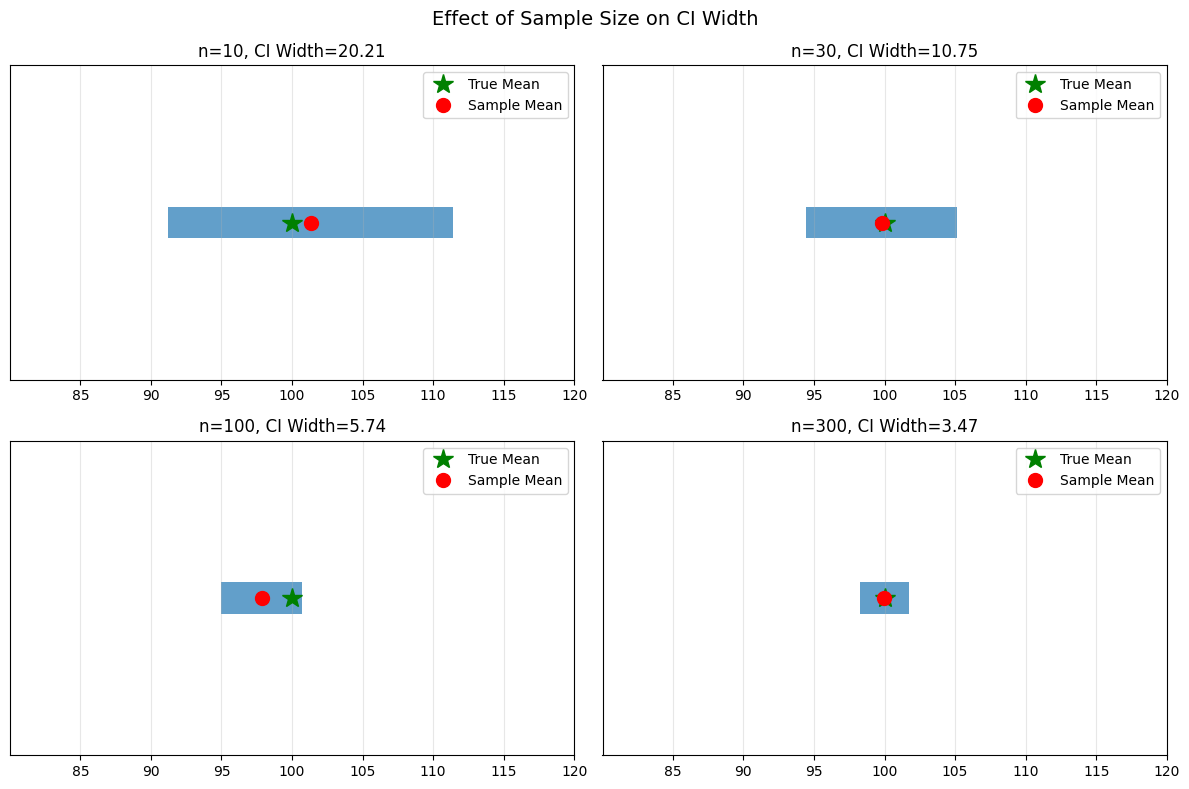

Confidence Interval Widths:
  n=10: width=20.21
  n=30: width=10.75
  n=100: width=5.74
  n=300: width=3.47

Larger sample → narrower interval (more precision)


In [7]:
# Larger samples = narrower confidence intervals

sample_sizes = [10, 30, 100, 300]
ci_widths = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    sample = np.random.choice(population, size=n, replace=False)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    sem = sample_std / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    
    ci_lower = sample_mean - t_crit * sem
    ci_upper = sample_mean + t_crit * sem
    ci_width = ci_upper - ci_lower
    ci_widths.append(ci_width)
    
    # Plot
    axes[idx].barh([0], [ci_width], left=ci_lower, height=0.1, alpha=0.7)
    axes[idx].plot(true_mean, 0, 'g*', markersize=15, label='True Mean')
    axes[idx].plot(sample_mean, 0, 'ro', markersize=10, label='Sample Mean')
    axes[idx].set_xlim(true_mean-20, true_mean+20)
    axes[idx].set_ylim(-0.5, 0.5)
    axes[idx].set_title(f'n={n}, CI Width={ci_width:.2f}')
    axes[idx].set_yticks([])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.suptitle('Effect of Sample Size on CI Width', fontsize=14)
plt.tight_layout()
plt.show()

print("Confidence Interval Widths:")
for n, width in zip(sample_sizes, ci_widths):
    print(f"  n={n}: width={width:.2f}")
print(f"\nLarger sample → narrower interval (more precision)")

---
## 4. Standard Error vs Standard Deviation

In [8]:
print("Standard Deviation vs Standard Error:")
print()
print("Standard Deviation (σ or s):")
print("  - Measures spread of DATA")
print("  - Shows variability within sample")
print("  - Same size regardless of sample size")
print()
print("Standard Error (SE):")
print("  - Measures spread of SAMPLE MEANS")
print("  - Shows uncertainty in estimate")
print("  - Decreases as sample size increases")
print(f"  - Formula: SE = σ / √n")
print()

sample = np.random.choice(population, size=30, replace=False)
sample_std = np.std(sample, ddof=1)
sample_sem = sample_std / np.sqrt(30)

print(f"Example with n=30:")
print(f"  Sample Std Dev: {sample_std:.2f}")
print(f"  Standard Error: {sample_sem:.2f}")
print(f"  Ratio (Std/SE): {sample_std/sample_sem:.1f} ≈ √30")

Standard Deviation vs Standard Error:

Standard Deviation (σ or s):
  - Measures spread of DATA
  - Shows variability within sample
  - Same size regardless of sample size

Standard Error (SE):
  - Measures spread of SAMPLE MEANS
  - Shows uncertainty in estimate
  - Decreases as sample size increases
  - Formula: SE = σ / √n

Example with n=30:
  Sample Std Dev: 15.13
  Standard Error: 2.76
  Ratio (Std/SE): 5.5 ≈ √30


---
## 5. Margin of Error

In [9]:
# Margin of Error (ME) = how much sample estimate could be off
# ME = critical_value × SE

sample = np.random.choice(population, size=50, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
sem = sample_std / np.sqrt(50)

# Different confidence levels
for conf_level in [0.90, 0.95, 0.99]:
    alpha = 1 - conf_level
    t_val = stats.t.ppf(1 - alpha/2, df=49)
    margin_error = t_val * sem
    
    print(f"{conf_level*100:.0f}% Confidence Level:")
    print(f"  t-critical: {t_val:.3f}")
    print(f"  Margin of Error: ±{margin_error:.2f}")
    print(f"  CI: [{sample_mean - margin_error:.2f}, {sample_mean + margin_error:.2f}]")
    print()

90% Confidence Level:
  t-critical: 1.677
  Margin of Error: ±2.85
  CI: [99.10, 104.79]

95% Confidence Level:
  t-critical: 2.010
  Margin of Error: ±3.41
  CI: [98.53, 105.36]

99% Confidence Level:
  t-critical: 2.680
  Margin of Error: ±4.55
  CI: [97.40, 106.49]



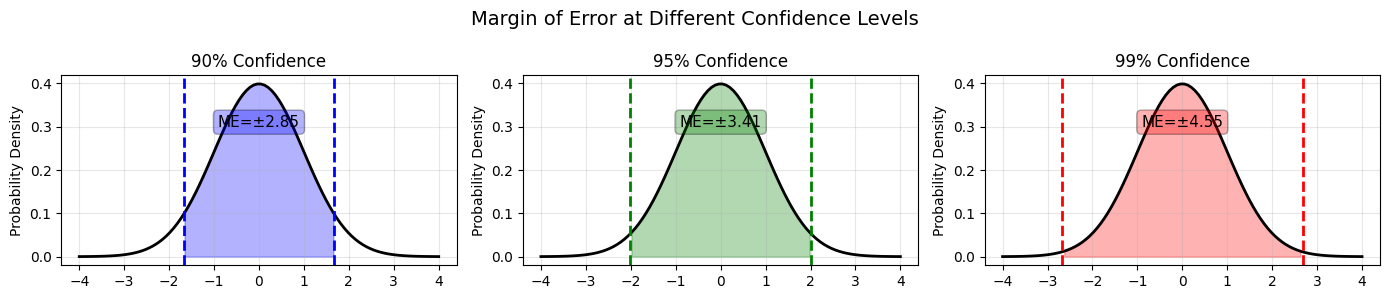

In [10]:
# Visualize confidence levels
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

conf_levels = [0.90, 0.95, 0.99]
colors = ['blue', 'green', 'red']

for idx, (conf, color) in enumerate(zip(conf_levels, colors)):
    alpha = 1 - conf
    t_val = stats.t.ppf(1 - alpha/2, df=49)
    margin_error = t_val * sem
    
    # Plot normal distribution
    x = np.linspace(-4, 4, 100)
    y = stats.norm.pdf(x)
    axes[idx].plot(x, y, 'k-', linewidth=2)
    
    # Shade confidence region
    x_shaded = x[np.abs(x) <= t_val]
    y_shaded = stats.norm.pdf(x_shaded)
    axes[idx].fill_between(x_shaded, y_shaded, alpha=0.3, color=color)
    
    # Mark bounds
    axes[idx].axvline(-t_val, color=color, linestyle='--', linewidth=2)
    axes[idx].axvline(t_val, color=color, linestyle='--', linewidth=2)
    
    axes[idx].set_title(f"{conf*100:.0f}% Confidence")
    axes[idx].set_ylabel('Probability Density')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].text(0, 0.3, f"ME=±{margin_error:.2f}", ha='center', fontsize=11,
                  bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

plt.suptitle('Margin of Error at Different Confidence Levels', fontsize=14)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Sampling Distribution** = Distribution of sample means
2. **Standard Error** = SE = σ/√n (decreases with larger n)
3. **Confidence Interval** = Range likely containing true parameter
4. **Margin of Error** = How far sample estimate could be off
5. **Trade-off** = Higher confidence → wider interval

---
## Your Turn

1. Draw 1000 samples and plot their 95% CIs
2. Calculate CI for different confidence levels
3. Show how CI width changes with sample size

In [11]:
# Your code here